In [1]:
import sqlite3
import duckdb
import re
import os



In [2]:
# Connect to math StackExchange database
db_path = "workload/math/math.db"
# Try alternative path if first doesn't exist
if not os.path.exists(db_path):
    db_path = os.path.join(os.path.dirname(os.getcwd()), "workload", "math", "math.db")
con = duckdb.connect(db_path)
all_tables = con.sql("select table_name from information_schema.tables").df()["table_name"].to_list()
print(f"Connected to database: {db_path}")
print(f"Tables: {all_tables}")


Connected to database: workload/math/math.db
Tables: ['Badges', 'CloseReasonTypes', 'Comments', 'LinkTypes', 'PostHistory', 'PostHistoryTypes', 'PostLinks', 'Posts', 'PostTypes', 'Tags', 'Users', 'Votes', 'VoteTypes']


In [3]:
#TODO support compound primary keys

primary_keys = con.sql("""
SELECT tc.table_name, c.column_name
FROM information_schema.table_constraints tc,
     information_schema.constraint_column_usage ccu,
     information_schema.columns as c
WHERE tc.constraint_schema = ccu.constraint_schema
  AND tc.constraint_name = ccu.constraint_name
  AND c.table_schema = tc.constraint_schema
  AND tc.table_name = c.table_name 
  AND ccu.column_name = c.column_name
  AND tc.constraint_type = 'PRIMARY KEY';
""").df().set_index("table_name").to_dict()["column_name"]
primary_keys


{'Badges': 'Id',
 'CloseReasonTypes': 'Id',
 'Comments': 'Id',
 'LinkTypes': 'Id',
 'PostHistory': 'Id',
 'PostHistoryTypes': 'Id',
 'PostLinks': 'Id',
 'PostTypes': 'Id',
 'Posts': 'Id',
 'Tags': 'Id',
 'Users': 'Id',
 'VoteTypes': 'Id',
 'Votes': 'Id'}

In [5]:
# Read foreign keys from JSON schema file since database has no constraints
import json

schema_json_path = "workload/math/stackoverflow.dbschema.json"
if not os.path.exists(schema_json_path):
    schema_json_path = os.path.join(os.path.dirname(os.getcwd()), "workload", "math", "stackoverflow.dbschema.json")

with open(schema_json_path, 'r') as f:
    schema_data = json.load(f)

foreign_keys = []
for table in schema_data['tables']:
    table_name = table['name']
    if 'foreign keys' in table:
        for fk in table['foreign keys']:
            fk_column = fk['column']
            ref_table = fk['foreign table']
            ref_column = fk['foreign column']
            join_predicate = f"{table_name}.{fk_column} = {ref_table}.{ref_column}"
            foreign_keys.append((table_name, ref_table, join_predicate))

foreign_keys


[('Badges', 'Users', 'Badges.UserId = Users.Id'),
 ('Posts', 'PostTypes', 'Posts.PostTypeId = PostTypes.Id'),
 ('Posts', 'Posts', 'Posts.AcceptedAnswerId = Posts.Id'),
 ('Posts', 'Posts', 'Posts.ParentId = Posts.Id'),
 ('Posts', 'Users', 'Posts.OwnerUserId = Users.Id'),
 ('Posts', 'Users', 'Posts.LastEditorUserId = Users.Id'),
 ('Comments', 'Posts', 'Comments.PostId = Posts.Id'),
 ('Comments', 'Users', 'Comments.UserId = Users.Id'),
 ('PostHistory',
  'PostHistoryTypes',
  'PostHistory.PostHistoryTypeId = PostHistoryTypes.Id'),
 ('PostHistory', 'Posts', 'PostHistory.PostId = Posts.Id'),
 ('PostHistory', 'Users', 'PostHistory.UserId = Users.Id'),
 ('PostLinks', 'Posts', 'PostLinks.PostId = Posts.Id'),
 ('PostLinks', 'Posts', 'PostLinks.RelatedPostId = Posts.Id'),
 ('PostLinks', 'LinkTypes', 'PostLinks.LinkTypeId = LinkTypes.Id'),
 ('Tags', 'Posts', 'Tags.ExcerptPostId = Posts.Id'),
 ('Tags', 'Posts', 'Tags.WikiPostId = Posts.Id'),
 ('Votes', 'VoteTypes', 'Votes.VoteTypeId = VoteTypes.Id

/tmp/ipykernel_585169/1049425101.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


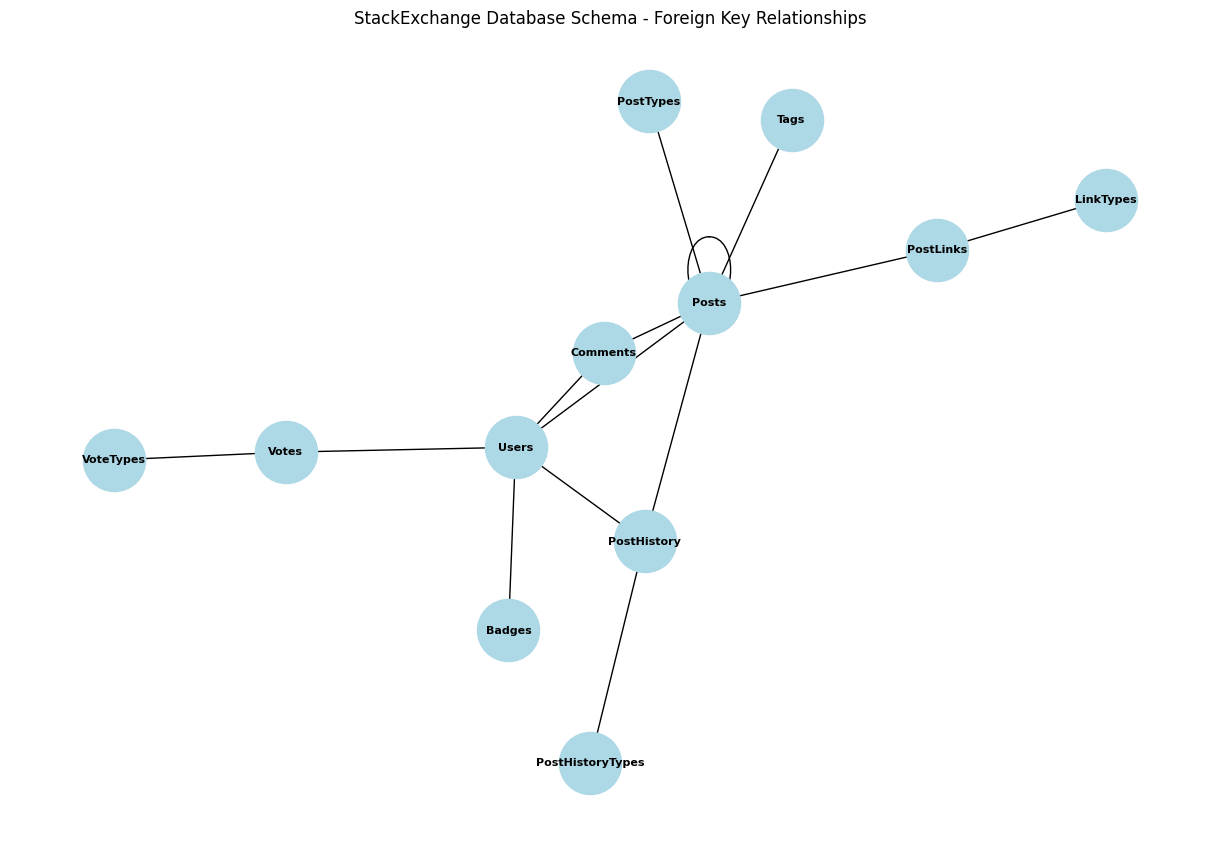

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for s, d, w in foreign_keys:
    G.add_edge(s, d, label=w)

plt.figure(figsize=(12, 8))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=2000, font_size=8, font_weight='bold')
plt.title("StackExchange Database Schema - Foreign Key Relationships")
plt.tight_layout()
plt.show()


/tmp/ipykernel_585169/3289334248.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


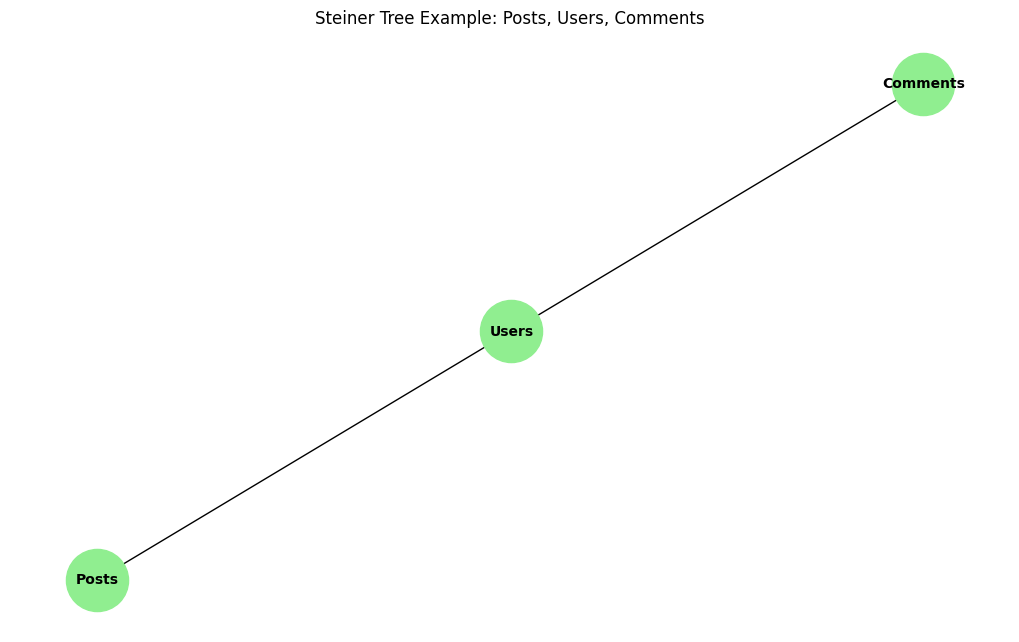

In [7]:
from networkx.algorithms import approximation
result = approximation.steiner_tree(G, ["Posts", "Users", "Comments"])
plt.figure(figsize=(10, 6))
nx.draw(result, with_labels=True, node_color='lightgreen', node_size=2000, font_size=10, font_weight='bold')
plt.title("Steiner Tree Example: Posts, Users, Comments")
plt.tight_layout()
plt.show()


In [8]:
con.sql("select column_name, column_type from (describe Posts) where key is null")


┌───────────────────────┬─────────────┐
│      column_name      │ column_type │
│        varchar        │   varchar   │
├───────────────────────┼─────────────┤
│ PostTypeId            │ SMALLINT    │
│ AcceptedAnswerId      │ INTEGER     │
│ ParentId              │ INTEGER     │
│ CreationDate          │ TIMESTAMP   │
│ Score                 │ INTEGER     │
│ ViewCount             │ INTEGER     │
│ Body                  │ VARCHAR     │
│ OwnerUserId           │ INTEGER     │
│ OwnerDisplayName      │ VARCHAR     │
│ LastEditorUserId      │ INTEGER     │
│ LastEditorDisplayName │ VARCHAR     │
│ LastEditDate          │ TIMESTAMP   │
│ LastActivityDate      │ TIMESTAMP   │
│ Title                 │ VARCHAR     │
│ Tags                  │ VARCHAR     │
│ AnswerCount           │ INTEGER     │
│ CommentCount          │ INTEGER     │
│ FavoriteCount         │ INTEGER     │
│ ClosedDate            │ TIMESTAMP   │
│ CommunityOwnedDate    │ TIMESTAMP   │
│ ContentLicense        │ VARCHAR     │


In [9]:
con.sql("select Score, count(*) cnt from Posts group by Score order by cnt desc limit 10")


┌───────┬─────────┐
│ Score │   cnt   │
│ int32 │  int64  │
├───────┼─────────┤
│     1 │ 1158405 │
│     0 │  985046 │
│     2 │  664282 │
│     3 │  360814 │
│     4 │  201600 │
│     5 │  116881 │
│     6 │   73145 │
│    -1 │   54090 │
│     7 │   47760 │
│     8 │   32787 │
├───────┴─────────┤
│     10 rows     │
└─────────────────┘

In [10]:
import json
string_col_schema = """
{
    "type": "object",
    "properties": {
      "column": { "type": "string", "const": "COL_NAME" },
      "filter": { "type": "string", "enum": ["random", "most_popular", "least_popular"] }
    },
    "required": ["column", "filter"],
    "additionalProperties": false
}
"""

int_col_schema = """
{
    "type": "object",
    "properties": {
      "column": { "type": "string", "const": "COL_NAME" },
      "op": { "type": "string", "enum": ["<", ">", "=", "!="] },
      "value": { "anyOf": [
          { "type": "number", "minimum": 0.0, "maximum": 1.0 },
          { "type": "string", "enum": ["most_popular", "least_popular"] }
      ]}
    },
    "required": ["column", "op", "value"],
    "additionalProperties": false
}
"""

table_schema = """
{
    "type": "object",
    "properties": {
        "table": { "type": "string", "const": "TABLE_NAME" },
        "filters": {
            "type": "array",
            "items": { "anyOf": COLUMN_SCHEMAS }
        }
    },
    "required": ["table"],
    "additionalProperties": false
}
"""
from jsonschema import validate


In [11]:
score_schema = json.loads(int_col_schema.replace("COL_NAME", "Score"))
validate(instance={"column": "Score", "op": "!=", "value": "most_popular"}, schema=score_schema)


In [12]:
cols = con.sql("select column_name, column_type from (describe Posts) where key is null").df()
col_schema = []
for _, d in cols.iterrows():
    cname = d["column_name"]
    ctype = d["column_type"]

    if "VARCHAR" in str(ctype) or "TEXT" in str(ctype):
        col_schema.append(json.loads(string_col_schema.replace("COL_NAME", cname)))
    elif "INTEGER" in str(ctype) or "SMALLINT" in str(ctype) or "BIGINT" in str(ctype):
        col_schema.append(json.loads(int_col_schema.replace("COL_NAME", cname)))

col_schema = json.dumps(col_schema)
posts_schema = table_schema.replace("TABLE_NAME", "Posts").replace("COLUMN_SCHEMAS", col_schema)
posts_schema = json.loads(posts_schema)


In [13]:
data = {"table": "Posts",
        "filters": [
            {"column": "Title", "filter": "random"},
            {"column": "Score", "op": "<", "value": 0.5}
        ]}
validate(instance=data, schema=posts_schema)


In [14]:
def grammar_for_table(table):    
    cols = con.sql(f"select column_name, column_type from (describe {table}) where key is null").df()
    col_schema = []
    filter_rules = []
    filter_names = []
    for _, d in cols.iterrows():
        cname = d["column_name"]
        if cname.endswith("_id") or cname.endswith("Id"):
            continue
        ctype = str(d["column_type"])
    
        filt_rule = f"{table}_{cname}_filter"
        if "VARCHAR" in ctype or "TEXT" in ctype:
            filter_rules.append(f"""{filt_rule}: "({cname} " strop ")" """)
        elif "INTEGER" in ctype or "SMALLINT" in ctype or "BIGINT" in ctype:
            filter_rules.append(f"""{filt_rule}: "({cname} " intop " " intval ")" """)
            
        filter_names.append(filt_rule)
    
    grammar = [
        f"""{table}_selector: "({table} " {" ".join(x + '?' for x in filter_names)} ")" """
    ]
    grammar.extend(filter_rules)
    grammar.append("")
    return grammar

grammar = ["start: " + " ".join(f"{x}_selector?" for x in all_tables)]
for table in all_tables:
    grammar.extend(grammar_for_table(table))

grammar = "\n".join(grammar)
grammar += """

intop: "<" | ">" | "=" | "!="
strop: "most_popular" | "random"

intval: "first" | "median" | "last" | "mode" | int int int int
int: "0" | "1" | "2" | "3" | "4" | "5" | "6" | "7" | "8" | "9"
"""

print(grammar)


start: Badges_selector? CloseReasonTypes_selector? Comments_selector? LinkTypes_selector? PostHistory_selector? PostHistoryTypes_selector? PostLinks_selector? Posts_selector? PostTypes_selector? Tags_selector? Users_selector? Votes_selector? VoteTypes_selector?
Badges_selector: "(Badges " Badges_Name_filter? Badges_Date_filter? Badges_Class_filter? Badges_TagBased_filter? ")" 
Badges_Name_filter: "(Name " strop ")" 
Badges_Class_filter: "(Class " intop " " intval ")" 

CloseReasonTypes_selector: "(CloseReasonTypes " CloseReasonTypes_Name_filter? ")" 
CloseReasonTypes_Name_filter: "(Name " strop ")" 

Comments_selector: "(Comments " Comments_Score_filter? Comments_Text_filter? Comments_CreationDate_filter? Comments_UserDisplayName_filter? Comments_ContentLicense_filter? ")" 
Comments_Score_filter: "(Score " intop " " intval ")" 
Comments_Text_filter: "(Text " strop ")" 
Comments_UserDisplayName_filter: "(UserDisplayName " strop ")" 
Comments_ContentLicense_filter: "(ContentLicense " str